# Statistics

Objectives:
- Visualize the Poisson distribution.
- Visualize the Guassian distribution.
- Visualize the moments of a distribution.
- Visualize the quantiles of a distribution.
    - Learn about important quantiles of the Guassian distribution.
- Visualize the law of large numbers.
- Visualize the central limit theorem.

In [1]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

## The Poisson Distribution

The Poisson distribution is defined on a discrete support: the natural numbers starting at 0.

The Poisson distribution is defined by one parameter, $\lambda$, the mean of the distribution.

Use [`scipy.stats.poisson`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html) to plot the probability mass function (PMF) of a Poisson distribution.

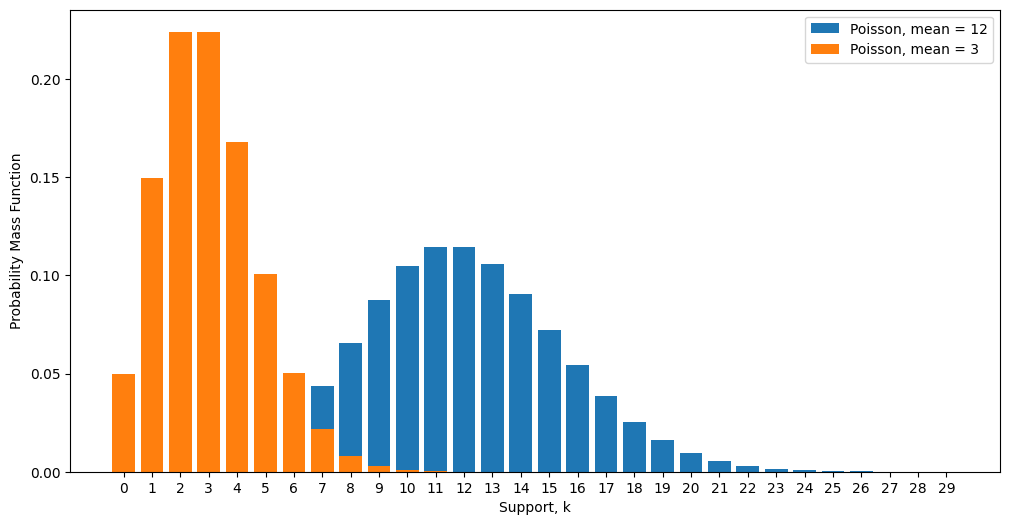

In [2]:
support = np.arange(30)
mu_poisson = 12
pmf_poisson = stats.poisson.pmf(support, 12)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(support, pmf_poisson, label="Poisson, mean = 12")
ax.bar(support, stats.poisson.pmf(support, 3), label="Poisson, mean = 3")

ax.set_xticks(support)
ax.set_xlabel("Support, k")
ax.set_ylabel("Probability Mass Function")

ax.legend()
fig.show()

## The Gaussian (Normal) Distribution

The Gaussian distribution is defined on a continuous support: all real numbers.

The Gaussian distribution is defined by two parameters: $\mu$, the mean of the distribution and $\sigma$, the standard deviation of the distribution.

Use [`scipy.stats.norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) to plot the probability density function (PDF) of a Gaussian (normal) distribution.

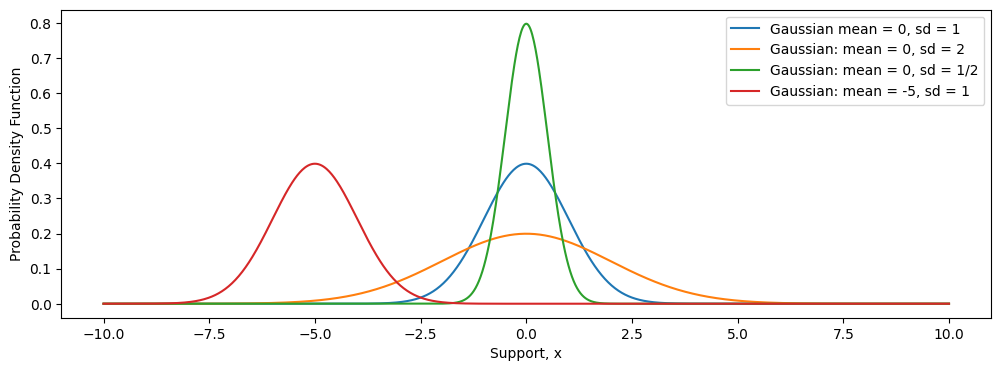

In [3]:
support = np.linspace(-10, 10, num=1001)
pdf_gaussian = stats.norm.pdf(support, 0, 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(support, pdf_gaussian, label="Gaussian mean = 0, sd = 1")
ax.plot(support, stats.norm.pdf(support, 0, 2), label="Gaussian: mean = 0, sd = 2")
ax.plot(support, stats.norm.pdf(support, 0, 1/2), label="Gaussian: mean = 0, sd = 1/2")
ax.plot(support, stats.norm.pdf(support, -5, 1), label="Gaussian: mean = -5, sd = 1")

ax.set_xlabel("Support, x")
ax.set_ylabel("Probability Density Function")

ax.legend(loc="upper right")
fig.show()

### The Moments of the Gaussian Distribution


Use [`scipy.stats.moment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.moment.html) to calculate and plot the second, third and fourth central moments of a Gaussian distribution.

In [4]:
support = np.linspace(-10, 10, num=1001)
pdf1 = stats.norm.pdf(support, loc=0, scale=1)

stats.norm.stats(loc=-1, scale=2, moments="mvsk")

(np.float64(-1.0), np.float64(4.0), np.float64(0.0), np.float64(0.0))

### The Quantiles of the Gaussian Distribution

Plot a Guassian PDF, and plot vertical lines at $\mathcal{N}(\mu \pm n \sigma)$ for $n = 1, 2, 3, 4, 5$.

Integrate the Gaussian PDF between $x = \mu - n \sigma$ and $x = \mu + n \sigma$. What percentage of the PDF does this integral account for, for each n?

Use [`scipy.stats.quantile`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.quantile.html) to calculate these quantiles.

![Gaussian](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Standard_deviation_diagram.svg/2560px-Standard_deviation_diagram.svg.png)

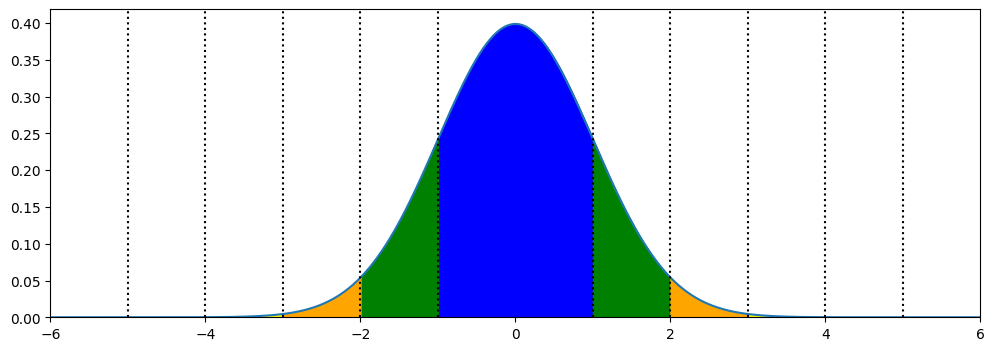

In [25]:
support = np.linspace(-100, 100, num=100_001)

mu = 0
sd = 1
pdf = stats.norm.pdf(support, loc=mu, scale=sd)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(support, pdf)

colors = [
    "blue", "green", "orange", "yellow", "red"
]

integrals = []
for i, n in enumerate(range(1, 5+1)):
    bounds = (mu - n * sd, mu + n * sd)
    ind = np.where(np.logical_and(support >= bounds[0], support <= bounds[1]))[0]
    integrals.append(np.trapezoid(pdf[ind], x=support[ind]))

    ax.axvline(x=bounds[0], color="black", ls=":")
    ax.axvline(x=bounds[1], color="black", ls=":")

    ind_neg = np.where(np.logical_and(support >= mu - n * sd, support <= mu - (n-1) * sd))[0]
    ind_pos = np.where(np.logical_and(support >= mu + (n-1) * sd, support <= mu + n * sd))[0]

    ax.fill_between(support[ind_neg], y1=pdf[ind_neg], color=colors[i])
    ax.fill_between(support[ind_pos], y1=pdf[ind_pos], color=colors[i])

ax.set_xlim((-6, 6))
ax.set_ylim((0, None))

fig.show()